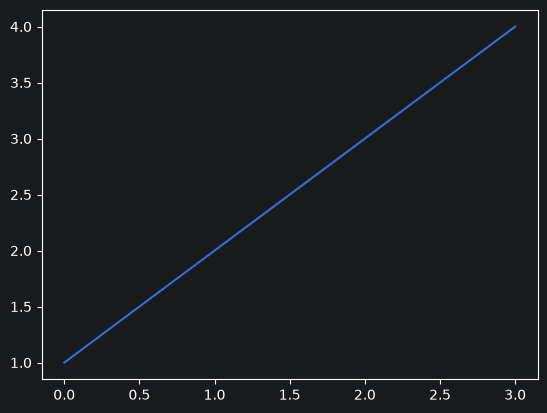

In [1]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4])
plt.show()

In [8]:
import matplotlib

print(matplotlib.get_backend())

inline


训练集原始形状： (60000, 785)
测试集原始形状： (10000, 785)
X_train: torch.Size([60000, 1, 28, 28])
y_train: torch.Size([60000])
X_test: torch.Size([10000, 1, 28, 28])
y_test: torch.Size([10000])
当前图片 shape： torch.Size([1, 28, 28])
当前图片 label： 4


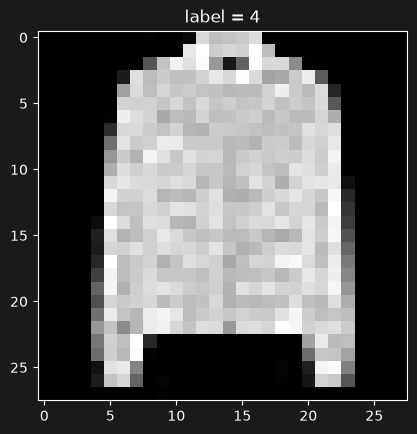

训练集样本数量： 60000
测试集样本数量： 10000


In [9]:
from torch.utils.data import DataLoader
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader


# =========================
# 1. 读取数据
# =========================

fashion_mnist_train = pd.read_csv(
    "../data/fashion-mnist_train.csv"
)

fashion_mnist_test = pd.read_csv(
    "../data/fashion-mnist_test.csv"
)

print("训练集原始形状：", fashion_mnist_train.shape)
print("测试集原始形状：", fashion_mnist_test.shape)


# =========================
# 2. 转换为 Tensor
# =========================

X_train = torch.tensor(
    fashion_mnist_train.iloc[:, 1:].values,
    dtype=torch.float32
).reshape(-1, 1, 28, 28)

y_train = torch.tensor(
    fashion_mnist_train.iloc[:, 0].values,
    dtype=torch.int64
)

X_test = torch.tensor(
    fashion_mnist_test.iloc[:, 1:].values,
    dtype=torch.float32
).reshape(-1, 1, 28, 28)

y_test = torch.tensor(
    fashion_mnist_test.iloc[:, 0].values,
    dtype=torch.int64
)


# =========================
# 3. 查看形状
# =========================

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# =========================
# 4. 显示一张图片
# =========================

index = 12345

print("当前图片 shape：", X_train[index].shape)
print("当前图片 label：", y_train[index].item())

plt.imshow(
    X_train[index, 0],
    cmap="gray"
)

plt.title(f"label = {y_train[index].item()}")
plt.show()


# =========================
# 5. 构建 Dataset
# =========================

train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

print("训练集样本数量：", len(train_dataset))
print("测试集样本数量：", len(test_dataset))

In [10]:
len(train_dataset)

60000

In [11]:
train_dataset[0]

(tensor([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   4.,   0.,   0.,   0.,   0.,   0.,  62.,
            61.,  21.,  29.,  23.,  51., 136.,  61.,   0.,   0.,   0.,   0.,
             0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.,  88., 201., 228., 225.,
           255., 115.,  62., 137., 255., 235., 222., 255., 135.,   0.,   0.,
             0.,   0.,   0.,   0.,   0

In [14]:
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=256,
    shuffle=True)
for X,y in train_loader:
    print('X.shape', X.shape)
    print('y.shape', y.shape)
    break


X.shape torch.Size([256, 1, 28, 28])
y.shape torch.Size([256])


In [16]:
# 搭建模型
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2),
    nn.Sigmoid(),

    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(6, 16, kernel_size=5),
    nn.Sigmoid(),

    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(400, 120),

    nn.Sigmoid(),

    nn.Linear(120, 84),

    nn.Sigmoid(),

    nn.Linear(84, 10),
)

torch.Size([1, 1, 28, 28])
输入： torch.Size([1, 1, 28, 28])
输出： torch.Size([1, 6, 28, 28])


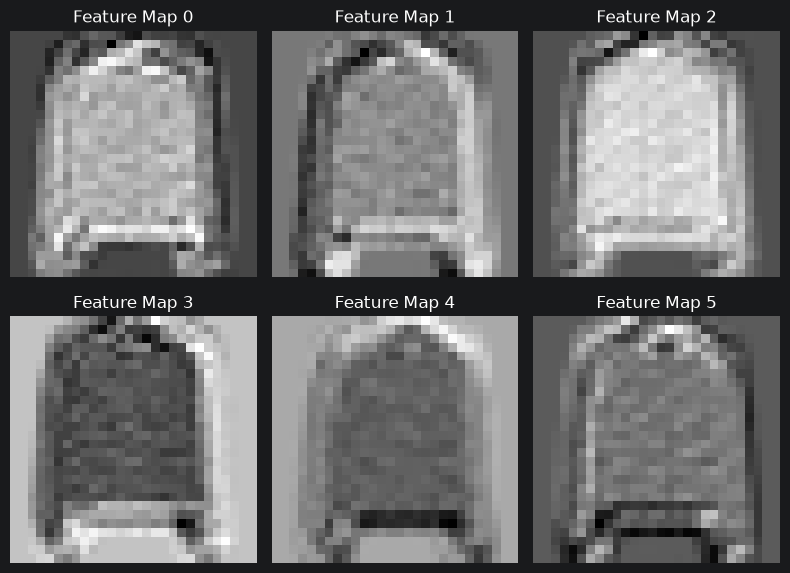

In [20]:
X = X_train[12345:12346]
print(X.shape)
conv1 = nn.Conv2d(
    1,
    6,
    kernel_size=5,
    padding=2
)

out = conv1(X)

print("输入：", X.shape)
print("输出：", out.shape)
fig, axes = plt.subplots(2, 3, figsize=(8, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        out[0, i].detach(),
        cmap="gray"
    )
    ax.set_title(f"Feature Map {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()